# E-Commerce Repurchase Propensity Modeling

## 1. Project Overview

- **Objective:** Develop a propensity model to predict which customers will make a repeat purchase within 90 days.
- **Strategy:** Rank customers by purchase probability to optimize marketing spend.
    - **High Probability:** "Natural Loyalists" -> Suppress from discounts to protect margin.
    - **Medium Probability:** "Persuadables" -> Target with retention/win-back offers.
    - **Low Probability:** "Lost Causes" -> Deprioritize to save budget.
- **Business Context:** In e-commerce, the top 10-20% of customers often drive 80% of revenue. Accurately identifying this cohort allows for high-ROI resource allocation rather than "spray and pray" marketing.
- **Target Variable:** `is_retained` (1 = Made a repeat purchase within 90 days, 0 = No purchase within 90 days).
- **Primary Metric:** **PR-AUC (Precision-Recall Area Under Curve)**.
    - *Why:* Since only ~12% of customers repurchase (imbalanced classes), standard accuracy is misleading. PR-AUC focuses specifically on how well we separate the "Positive" (Purchasers) class from the noise, balancing the need to capture revenue (Recall) with the need to avoid wasted ad spend (Precision).
- **Data Source:** [TheLook E-Commerce](https://console.cloud.google.com/marketplace/product/bigquery-public-df/thelook-ecommerce) (BigQuery public dataset)

## 2. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    average_precision_score, roc_auc_score, accuracy_score, recall_score, f1_score, precision_score)

import joblib

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

In [9]:
DATA_PATH = "../data/raw/propensity_data.csv"
MODEL_PATH = "../models/propensity_model.pkl"

## 3. Data Loading

In [10]:
# Load dataset
df = pd.read_csv(DATA_PATH)

In [11]:
# Initial inspection
print("Shape:", df.shape)
df.head()

Shape: (30549, 21)


,user_id,days_since_last_order,total_orders,total_spend,avg_order_value,returned_orders,return_rate,customer_tenure_days,age,gender,traffic_source,country,total_sessions,total_events,days_since_last_visit,avg_events_per_session,distinct_event_types,cart_events,product_view_events,purchase_events,is_retained
0,58455,322,9,538.400000,59.822222,0,0.000000,843,31,F,Search,China,9,85,322,9.444444,5,25,25,9,0
1,717,326,6,187.470001,31.245000,0,0.000000,2315,24,F,Facebook,Brasil,6,49,326,8.166667,5,14,14,6,1
2,4067,232,7,343.249998,49.035714,2,0.285714,985,65,F,Search,China,7,47,232,6.714286,5,13,13,7,0
3,33719,73,7,207.860000,29.694286,0,0.000000,545,66,M,Search,Brasil,7,54,73,7.714286,5,15,15,7,0
4,19742,12,6,232.889999,38.815000,3,0.500000,1030,65,M,Search,United States,6,49,12,8.166667,5,14,14,6,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30549 entries, 0 to 30548
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 30549 non-null  int64  
 1   days_since_last_order   30549 non-null  int64  
 2   total_orders            30549 non-null  int64  
 3   total_spend             30549 non-null  float64
 4   avg_order_value         30549 non-null  float64
 5   returned_orders         30549 non-null  int64  
 6   return_rate             30549 non-null  float64
 7   customer_tenure_days    30549 non-null  int64  
 8   age                     30549 non-null  int64  
 9   gender                  30549 non-null  object 
 10  traffic_source          30549 non-null  object 
 11  country                 30549 non-null  object 
 12  total_sessions          30549 non-null  int64  
 13  total_events            30549 non-null  int64  
 14  days_since_last_visit   30549 non-null

## 4. Data Cleaning & Preprocessing

In [13]:
# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [14]:
# Check for missing values
print(df.isna().sum())

user_id                   0
days_since_last_order     0
total_orders              0
total_spend               0
avg_order_value           0
returned_orders           0
return_rate               0
customer_tenure_days      0
age                       0
gender                    0
traffic_source            0
country                   0
total_sessions            0
total_events              0
days_since_last_visit     0
avg_events_per_session    0
distinct_event_types      0
cart_events               0
product_view_events       0
purchase_events           0
is_retained               0
dtype: int64


In [15]:
# Check if these events are exactly same
eq_rate = (df['product_view_events'] == df['cart_events']).mean()
diff = (df['product_view_events'] - df['cart_events'])

print("cart_events == product_view_events (%):", eq_rate)
print(diff.describe())

cart_events == product_view_events (%): 1.0
count    30549.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64


In [16]:
# Drop product_view_events
df.drop(columns=['product_view_events'], inplace=True)

**Note**: In this dataset, `product_view_events` and `cart_events` are perfectly correlated (identical counts for all users). This suggests these events are logged together and do not represent distinct funnel steps. As a result, `product_view_events` is excluded from modeling/feature engineering.

## 5. Exploratory Data Analysis (EDA)

In [17]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,30549.0,NaN,NaN,NaN,49921.02203,28650.270374,2.0,25334.0,49801.0,74698.0,100000.0
days_since_last_order,30549.0,NaN,NaN,NaN,154.355102,104.298899,1.0,62.0,140.0,240.0,364.0
total_orders,30549.0,NaN,NaN,NaN,2.37448,1.646057,1.0,1.0,2.0,3.0,13.0
total_spend,30549.0,NaN,NaN,NaN,141.259695,141.253166,0.02,44.950001,96.460001,191.780003,1655.289993
avg_order_value,30549.0,NaN,NaN,NaN,59.537429,51.801664,0.02,30.0,46.990002,71.5,999.0
returned_orders,30549.0,NaN,NaN,NaN,0.234639,0.656952,0.0,0.0,0.0,0.0,8.0
return_rate,30549.0,NaN,NaN,NaN,0.098629,0.262733,0.0,0.0,0.0,0.0,1.0
customer_tenure_days,30549.0,NaN,NaN,NaN,968.371141,664.546265,4.0,406.0,815.0,1463.0,2464.0
age,30549.0,NaN,NaN,NaN,41.04429,17.043218,12.0,26.0,41.0,56.0,70.0
gender,30549,2,F,15281,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Class Distribution

In [18]:
# Check target balance
retention_rate = df["is_retained"].mean()
print(f"Retention Rate (Repurchase Rate): {retention_rate:.1%}")
print(f"\nClass distribution:")
df["is_retained"].value_counts().rename({1: 'Retained', 0: 'Churned'})

Retention Rate (Repurchase Rate): 11.6%

Class distribution:


is_retained
Churned     27003
Retained     3546
Name: count, dtype: int64

#### Note on Class Imbalance

Only ~12% of customers make a repeat purchase within 90 days. This is typical for non-subscription fashion e-commerce where most customers are one-time buyers.

**Implications for modeling**:
- Accuracy is misleading - a "predict no one returns" baseline achieves 88%.
- We optimize for **PR-AUC** to balance precision and recall on the minority class.
- Business value comes from correctly ranking the 12% most likely to convert.

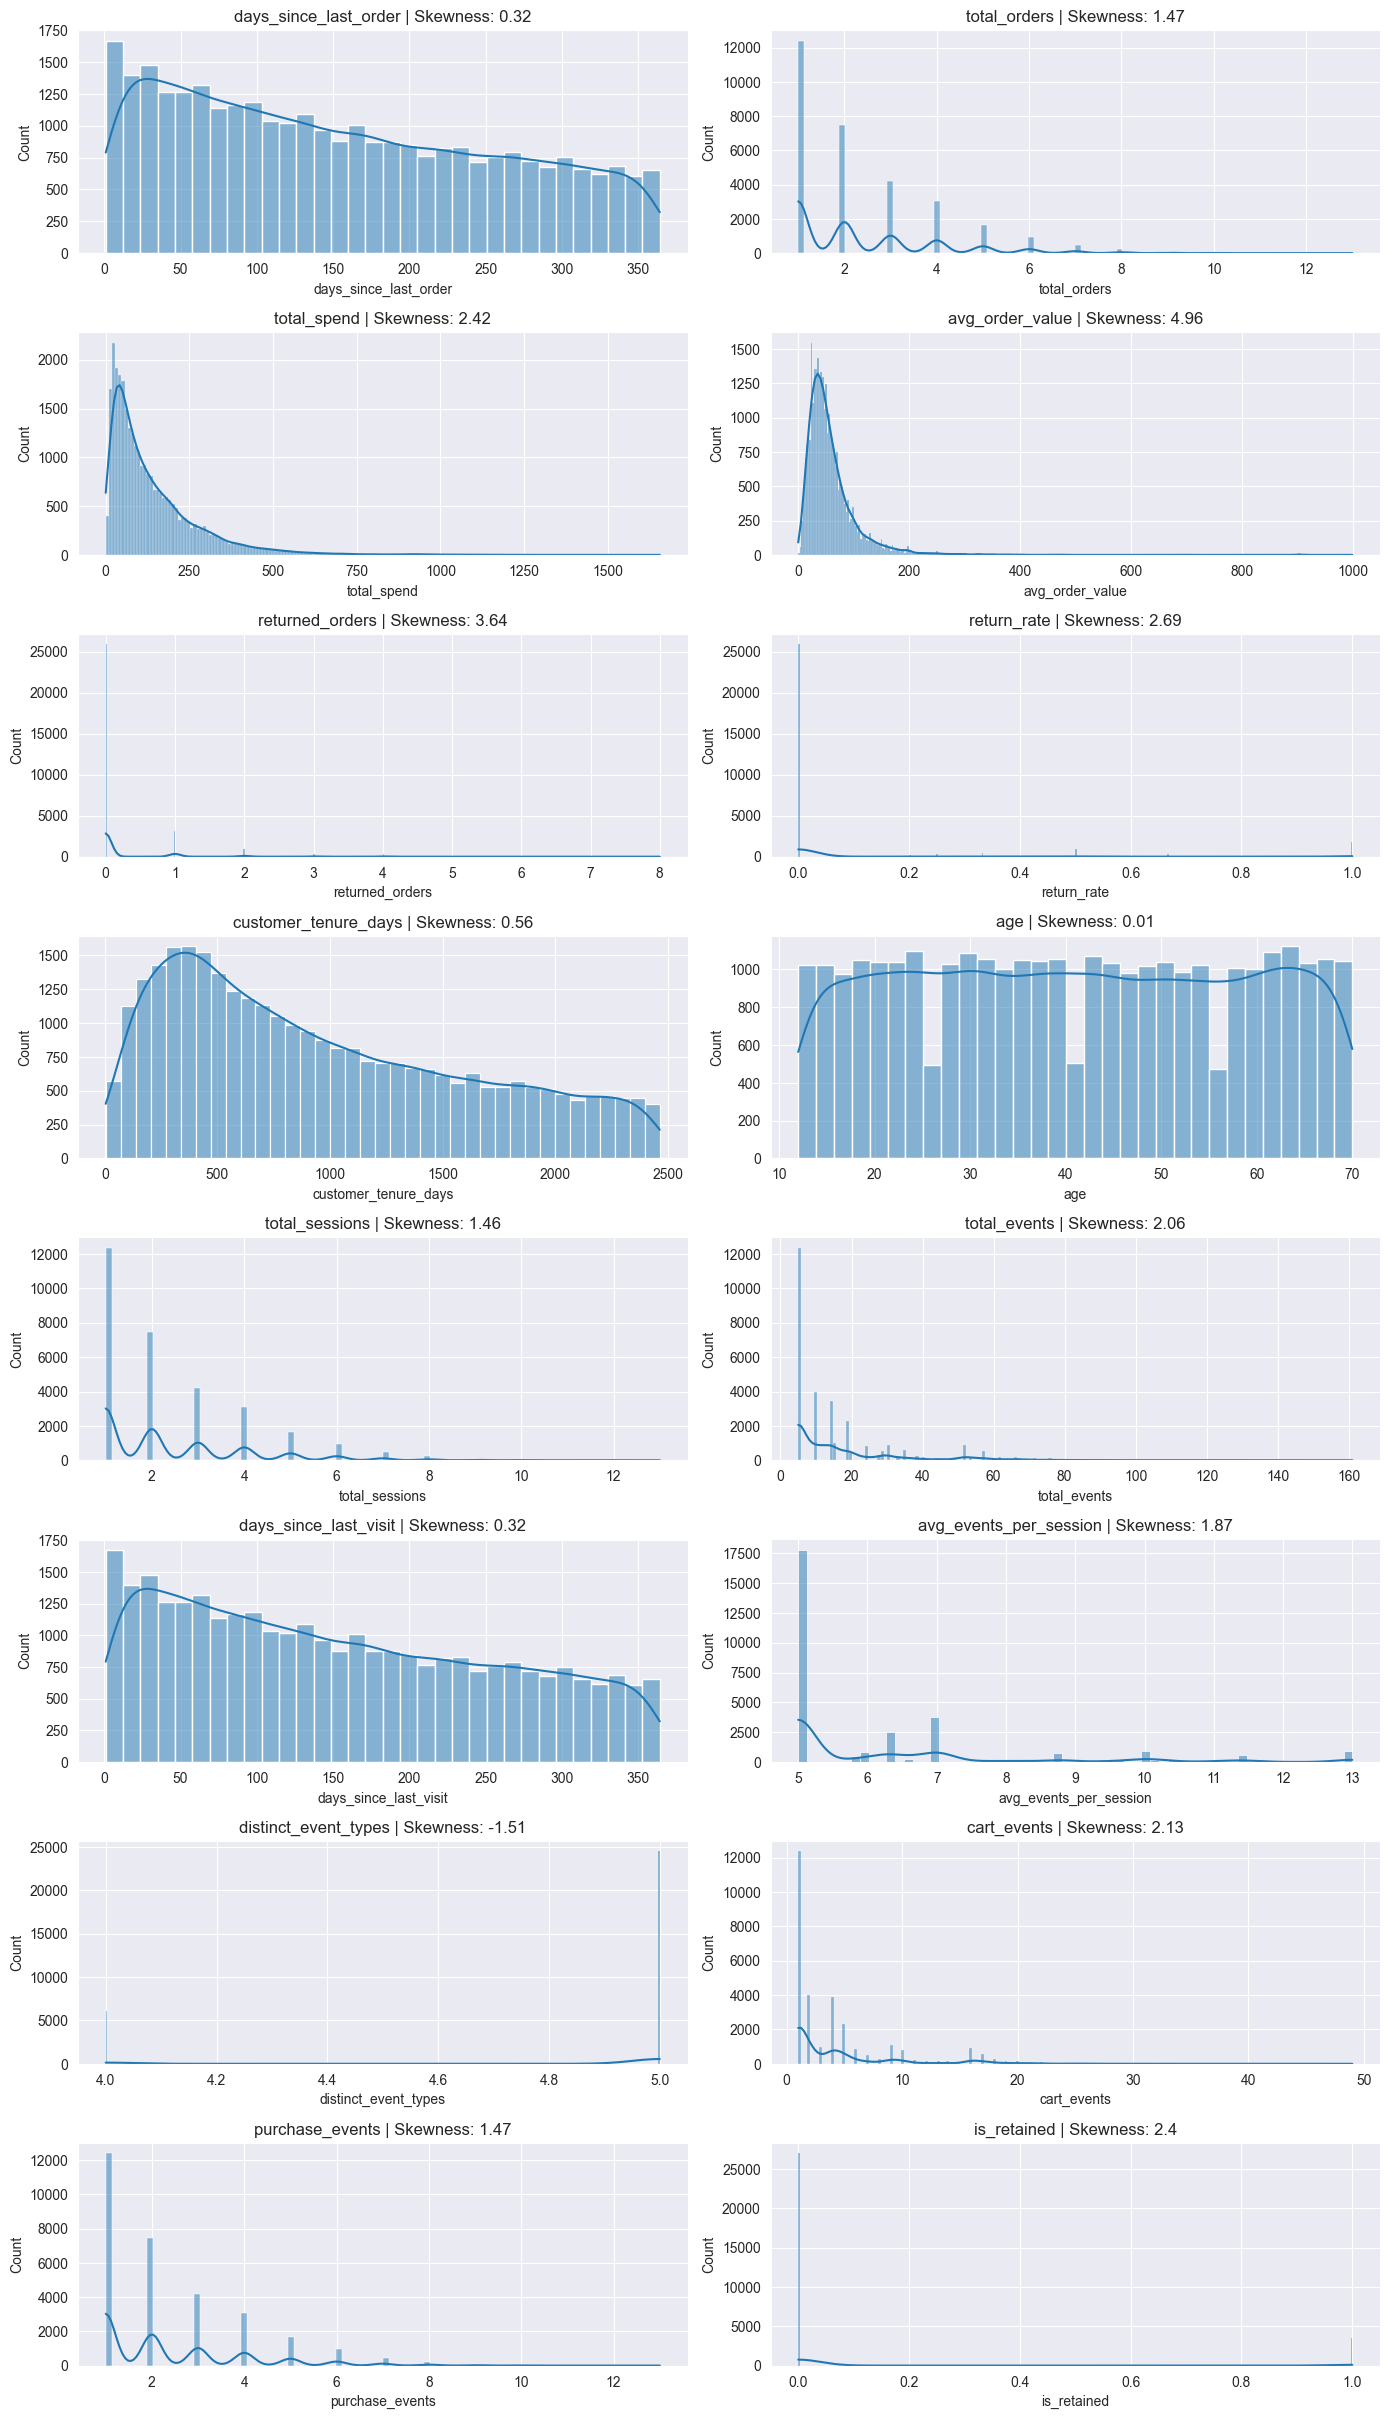

In [19]:
# Distribution of numerical features
numerical_features = (df.drop(columns='user_id')).select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14, len(numerical_features) * 3))
for idx, feature in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

### Transactional Features (recency, spend, returns)

#### 🔎 Insight 1: The "60-Day Cliff"

**Hypothesis:** Recent customers are more likely to repurchase - but when does the window close?

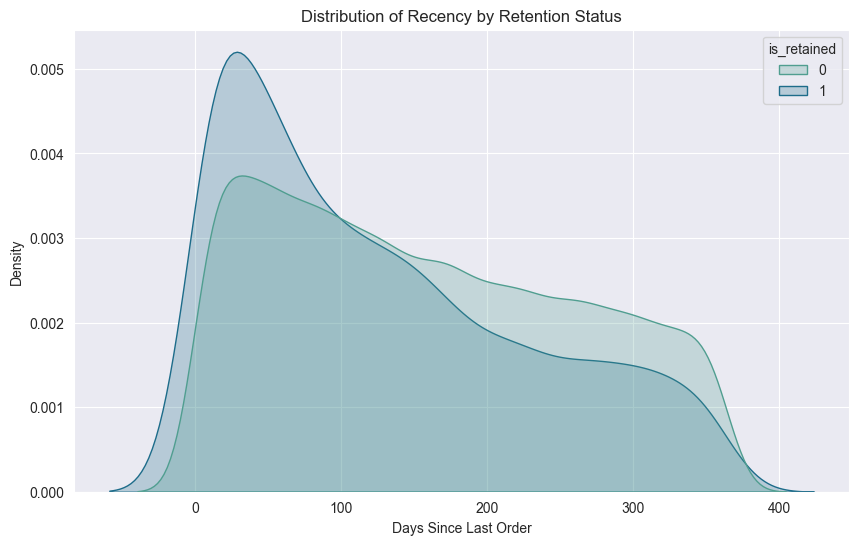

In [25]:
# Visualizing the separation between Retained (1) and Churned (0)
# The density plot below separates users who stayed (Dark Blue, 1) vs. those who churned (Light Teal, 0).
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, x='days_since_last_order', hue='is_retained', 
    fill=True, 
    common_norm=False,  # scale each distribution independently since the classes are imbalanced!
    palette='crest'
    )
plt.title("Distribution of Recency by Retention Status")
plt.xlabel("Days Since Last Order")
plt.show()

**Finding:** Retained customers are concentrated in the 0-60 day range. Beyond 100 days, almost no one comes back.

> 💡 **Implication:** Customers inactive for 60+ days belong in the "Lost Causes" tier. Marketing spend here has minimal ROI. Focus retention offers on the 30-60 day window where "Persuadables" live.

#### 🔎 Insight 2: Returns Don't Hurt Retention

**Hypothesis:** Users who return items often are less likely to repurchase. (i.e., high return $\propto$ 1/repurchase rate)

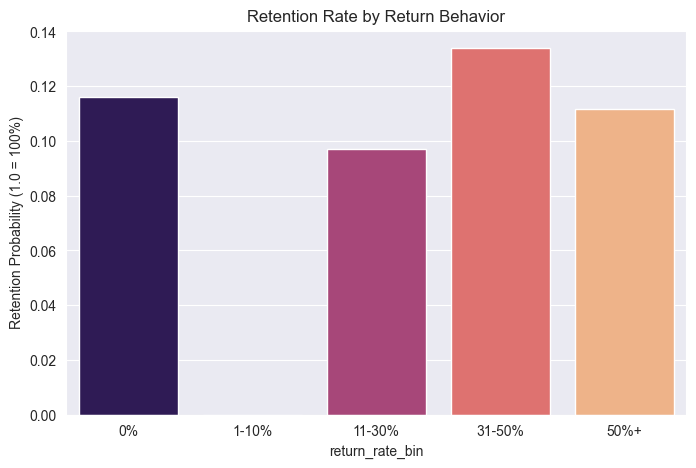

In [27]:
# Binning Return Rate to see trends
df['return_rate_bin'] = pd.cut(
    df['return_rate'], 
    bins=[-0.1, 0, 0.1, 0.3, 0.5, 1.0], 
    labels=["0%", "1-10%", "11-30%", "31-50%", "50%+"])

plt.figure(figsize=(8, 5))

# Look at the % of people who retained in each bin
sns.barplot(data=df, x='return_rate_bin', y='is_retained', errorbar=None, hue='return_rate_bin', palette='magma')
plt.title("Retention Rate by Return Behavior")
plt.ylabel("Retention Probability (1.0 = 100%)")
plt.show()

**Finding:** Retention rate is consistently low (~11-15%) across all return rate buckets. Serial returners are not less likely to come back.

> 💡 **Implication:** Don't penalize high-return customers in propensity scoring. Return behavior is not a useful signal for identifying "Lose Causes."

#### 🔎 Insight 3: High Spenders Aren't Guaranteed Loyalists

**Hypothesis:** High-value customers ("Whales") are more likely to repurchase.

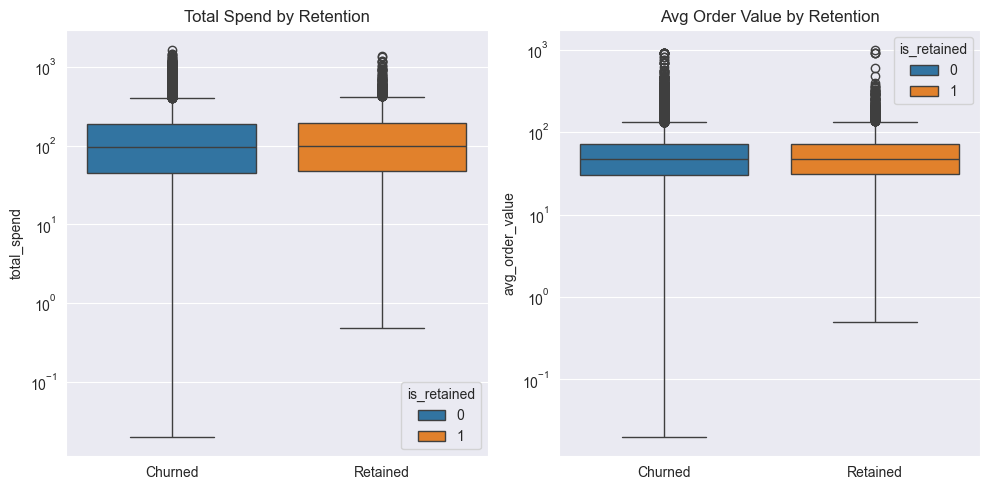

In [28]:
# Compare the distribution of lifetime spend between Churned (0) and Retained (1) users to see if "VIPs" stick around longer
features = ['total_spend', 'avg_order_value']
target = 'is_retained'

fig, axes = plt.subplots(1, len(features), figsize=(5 * len(features), 5))

for i, feature in enumerate(features):
    sns.boxplot(data=df, x=target, y=feature, hue=target, ax=axes[i])
    axes[i].set_title(f"{feature.replace("_", " ").title().replace("Per", "per")} by Retention")
    axes[i].set_xticklabels(['Churned', 'Retained'])
    axes[i].set_xlabel('')
    axes[i].set_yscale('log')   # log scale helps since spend is usually skewed
    
plt.tight_layout()
plt.show()

**Finding:** Spend distributions are nearly identical between retained and churned customers. High spenders leave at the same rate as low spenders.

> 💡 **Implication:** Don't auto-classify high spenders as "Natural Loyalists." Historical spend alone doesn't predict future purchase probability - recency and frequency are stronger signals.

### Engagement Features (sessions, cart events)

#### 🔎 Insight 4: Site Engagement Predicts Retention

**Hypothesis:** Customers who browse more frequently are more likely to repurchase.

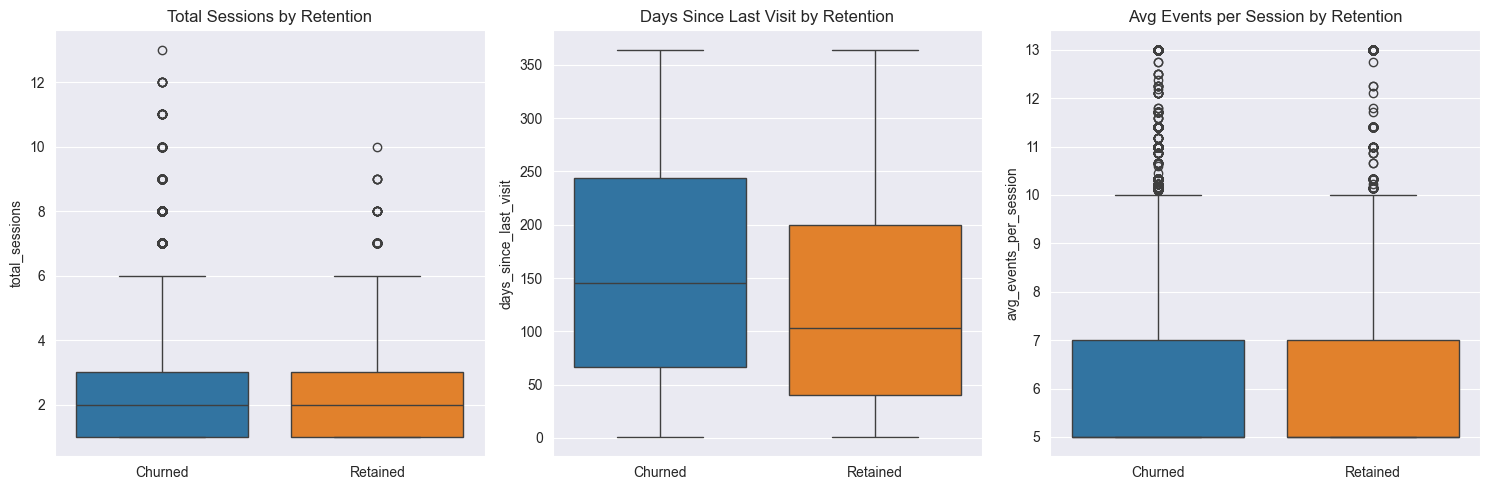

--- Engagement Metrics by Retention ---
is_retained             Churned  Retained
total_sessions              2.0       2.0
days_since_last_visit     145.0     103.0
avg_events_per_session      5.0       5.0
total_events               10.0      10.0


In [29]:
# Session activity vs. retention_rate
features = ['total_sessions', 'days_since_last_visit', 'avg_events_per_session']
target = 'is_retained'

fig, axes = plt.subplots(1, len(features), figsize=(5 * len(features), 5))

for i, feature in enumerate(features):
    sns.boxplot(data=df, x=target, y=feature, hue=target, legend=False, ax=axes[i])
    axes[i].set_title(f"{feature.replace("_", " ").title().replace("Per", "per")} by Retention")
    axes[i].set_xticklabels(['Churned', 'Retained'])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# Statistical summary
print("--- Engagement Metrics by Retention ---")
engagement_cols = ['total_sessions', 'days_since_last_visit', 'avg_events_per_session', 'total_events']
print(df.groupby('is_retained')[engagement_cols].median().round(2).rename(index={0: 'Churned', 1:'Retained'}).T)

**Finding:** Retained customers have more recent site visits. Median days since last visit lower for retained users (103 days) compared to churned users (145 days). However, overall engagement volume is similar across groups: median total sessions (2), total events (10), and average events per session (5) are nearly identical.

> 💡 **Implication:** **Recency of engagement** is a stronger retention signal than raw engagement volume. Focus retention interventions on customers whose `days_since_last_visit` is increasing (e.g., reactivation campaigns, reminders), rather than targeting based only on how many sessions/events they had historically.

#### 🔎 Insight 5: Cart Activity Signals

**Hypothesis:** Customers who add items to cart (even without purchasing) show higher future purchase probability.

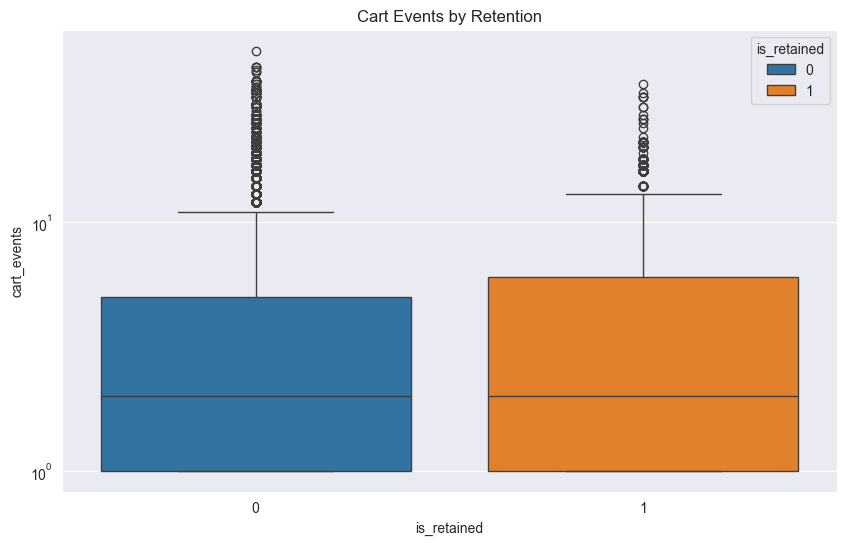

is_retained
Churned     2.0
Retained    2.0
Name: cart_events, dtype: float64

In [30]:
# Cart events vs. retention
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_retained', y='cart_events', hue='is_retained')
plt.title('Cart Events by Retention')
plt.yscale('log')
plt.show()

display(df.groupby('is_retained')['cart_events'].median().rename(index={0: 'Churned', 1: 'Retained'}))

**Finding:** Median cart activity is identical for churned and retained users (2 events). The distributions largely overlap, indicating that cart frequency alone is not a strong predictor of retention.

> 💡 **Implication:** Add-to-cart behavior by itself is insufficient for identifying high-retention users. Retention efforts should incorporate downstream behaviors (checkout, ,purchase, completion, repeat purchase) rather than cart activity alone.

### Demographic Features (age, traffic source)

#### 🔎 Insight 6: Acquisition Channel Matters

**Hypothesis:** Organic customers (Search, direct traffic) are more loyal than paid acquisition (Facebook, Display ads).

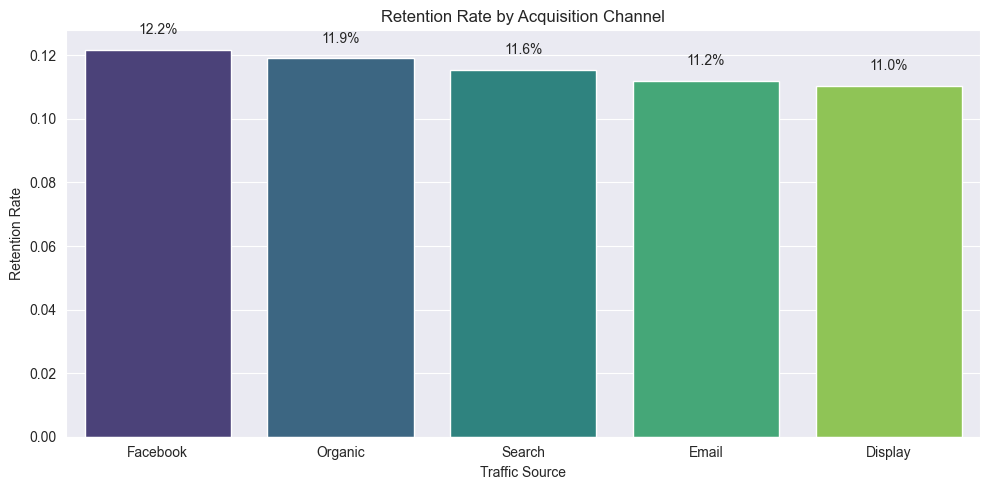

                Retention Rate  Customer Count
traffic_source                                
Facebook                 0.122            1856
Organic                  0.119            4545
Search                   0.116           21436
Email                    0.112            1535
Display                  0.110            1177


In [31]:
# Retention rate by traffic source
traffic_retention = df.groupby('traffic_source')['is_retained'].agg(['mean', 'count']).sort_values('mean', ascending=False)
traffic_retention.columns = ['Retention Rate', 'Customer Count']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df, x='traffic_source', y='is_retained',
                 order=traffic_retention.index, palette='viridis', errorbar=None)
plt.title('Retention Rate by Acquisition Channel')
plt.ylabel('Retention Rate')
plt.xlabel('Traffic Source')

# Add value labels
for i, v in enumerate(traffic_retention['Retention Rate']):
    ax.text(i, v+0.005, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

print(traffic_retention.round(3))

**Finding:** Retention rates by channel are very close (range ~11%-12.2%). Facebook is highest (12.2%) and Display is lowest (11%), but the lift is only ~1.2 pp. Channel volumes differ a lot (e.g., Search has far more customers than Facebook), so rank-ordering may be noisy.

> 💡 **Implication:** Facebook *may* be a higher-quality acquisition channel, but the observed lift is small and Facebook has a much smaller sample. Validate with statistical testing and incremental performance (CAC/LTV) before reallocating budget.

#### 🔎 Insight 7: Customer Tenure and Age Patterns

**Hypothesis:** Established customers (longer tenure) and certain age groups are more likely to repurchase.

In [32]:
df_plot = df.copy()
df_plot['retention_label'] = df_plot['is_retained'].map({
    0: 'Churned',
    1: 'Retained'
})

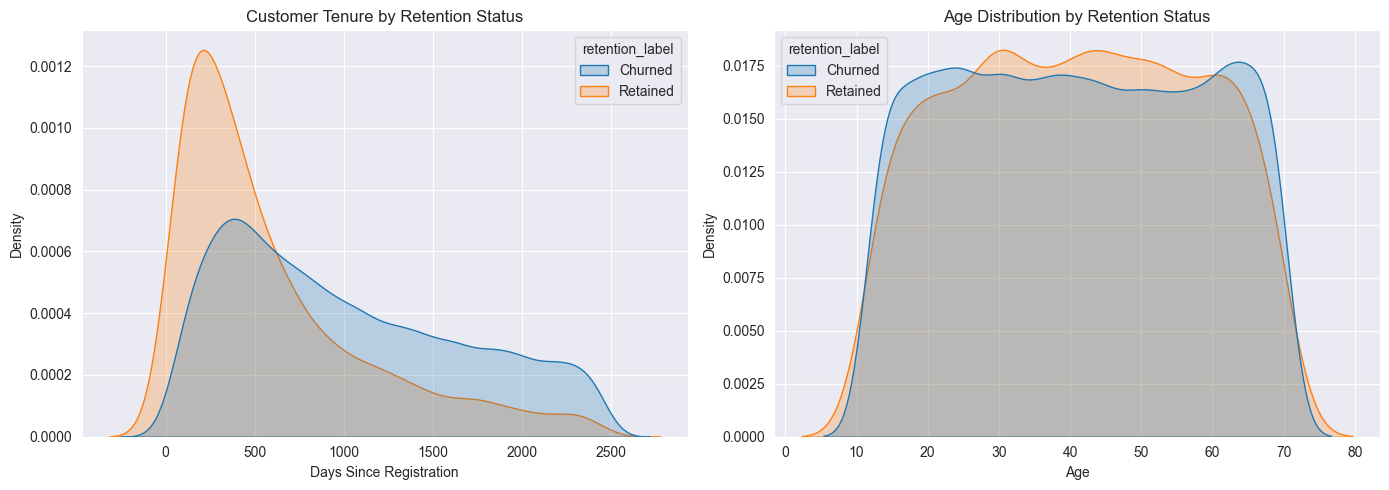

--- Retention Rate by Age Group ---
age_group
46-55    0.126
26-35    0.122
36-45    0.122
55+      0.109
18-25    0.109
Name: is_retained, dtype: float64

--- Customer Tenure by Retention Status ---
             count         mean  median
is_retained                            
0            27003  1016.358738   880.0
1             3546   602.942752   409.0


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.kdeplot(
    data=df_plot,
    x='customer_tenure_days',
    hue='retention_label',
    hue_order=['Churned', 'Retained'],
    common_norm=False,
    fill=True,
    ax=axes[0]
)
axes[0].set_title('Customer Tenure by Retention Status')
axes[0].set_xlabel('Days Since Registration')

sns.kdeplot(
    data=df_plot,
    x='age',
    hue='retention_label',
    hue_order=['Churned', 'Retained'],
    common_norm=False,
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Age Distribution by Retention Status')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Age buckets
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])
age_retention = df.groupby('age_group', observed=True)['is_retained'].mean().sort_values(ascending=False)

print('--- Retention Rate by Age Group ---')
print(age_retention.round(3))

print(f"\n--- Customer Tenure by Retention Status ---")
print(df.groupby('is_retained')['customer_tenure_days'].agg(['count', 'mean', 'median']))

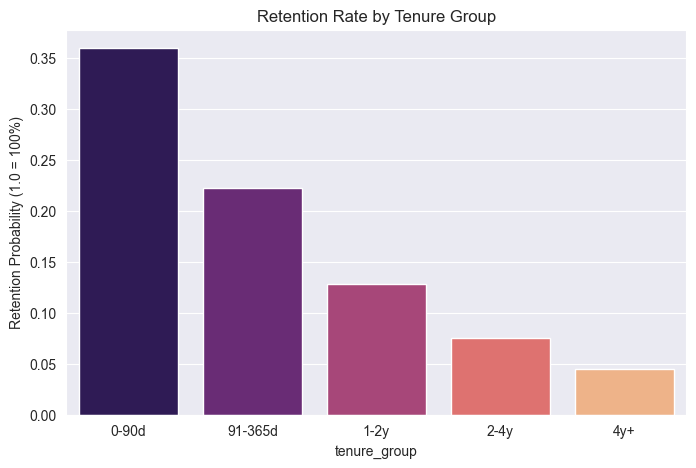

In [35]:
# Binning customer tenure to see trends
df["tenure_group"] = pd.cut(
    df["customer_tenure_days"], 
    bins=[-0.1, 90, 365, 730, 1460, np.inf],
    labels=["0-90d", "91-365d", "1-2y", "2-4y", "4y+"]
)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='tenure_group', y='is_retained', errorbar=None, hue='tenure_group', palette='magma')
plt.title("Retention Rate by Tenure Group")
plt.ylabel("Retention Probability (1.0 = 100%)")
plt.show()

**Finding:** 
- Customers who repurchase within 90 days ("retained") tend to be **newer customers**, while customers who do not repurchase within 90 days skew toward **longer tenure**. In this dataset, the retained group has a lower customer tenure (median 409 days) than the non-retained group (median 880 days), suggesting retention in this definition is driven more by **recent purchasing activity** than by how long ago the customer first registered.
- Retention rate varies only modestly by age group (range ~10.9%-12.6%). The 46-55 group has the highest observed retention (12.6%), while 18-25 and 55+ are lowest (~10.9%), indicating age is a weak differentiator relative to behavior/lifecycle signals.

> 💡 **Implication:** 
> - Segment and intervene by **lifecycle stage** rather than assuming longer-tenure customers are more loyal. Newer customers appear more likely to repurchase within 90 days, so prioritize early-lifecycle strategies (onboarding, second-purchase nudges) to increase repeat purchases quickly. For long-tenure customers, focus on **reactivation** (win-back campaigns triggered by inactivity) since many may be "lapsed" under the 90-day definition. 
> - Age can be included as a secondary feature, but it likely won't drive strategy on its own. 
> - These features are more useful for segmentation than prediction (e.g., tailoring offer messaging by age group rather than determining who to target).

#### 🔎 Insight 8: Geographic Retention Patterns

**Hypothesis:** Retention rates vary by country/market due to competitive landscape and shipping experience.

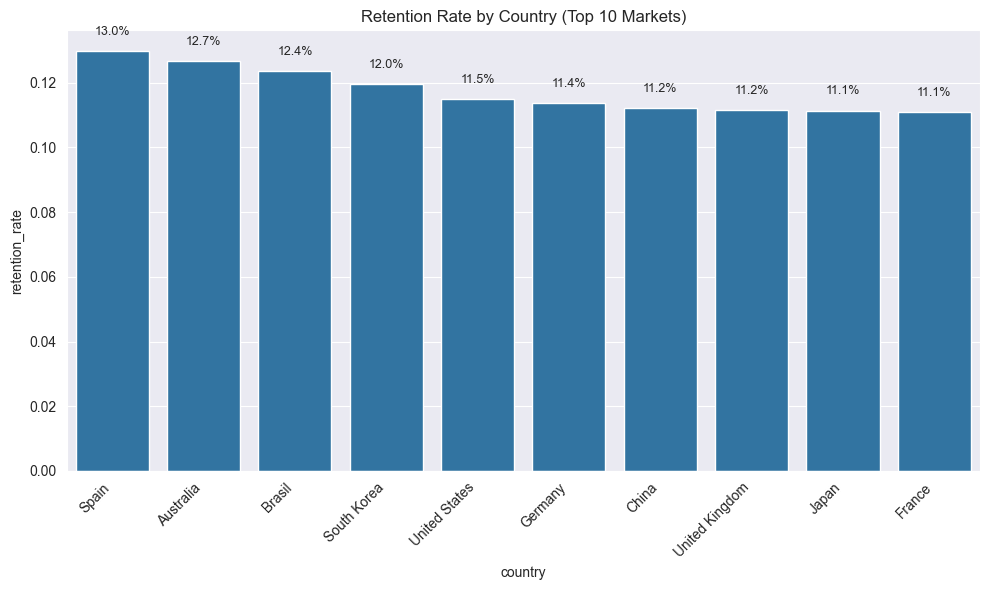

--- Top 10 Markets ---
                retention_rate  customers
country                                  
Spain                 0.129704       1249
Australia             0.126801        694
Brasil                0.123664       4399
South Korea           0.119653       1613
United States         0.114840       6853
Germany               0.113768       1213
China                 0.112076      10368
United Kingdom        0.111570       1452
Japan                 0.111406        754
France                0.111036       1486


In [36]:
# Top 10 countries by volume
top_countries = df['country'].value_counts().head(10).index

# Retention by country
country_retention = (
    df[df['country'].isin(top_countries)]
    .groupby('country')['is_retained']
    .agg(retention_rate='mean', customers='count')
    .sort_values('retention_rate', ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=country_retention.index, y=country_retention['retention_rate'])
plt.title('Retention Rate by Country (Top 10 Markets)')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(country_retention['retention_rate']):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"--- Top 10 Markets ---")
print(country_retention)

**Finding:** Retention rates vary modestly by country (~11.1%-13%). Spain, Australia, and Brazil show the highest retention, while France and Japan are lowest. Overall differences are small (~2 pp).

> 💡 **Implication:** Country has a limited but meaningful impact on retention. Focus on learning from higher-performing markets and testing localized improvements in lower-performing ones, rather than making major budget shifts based on geography alone. Also, be cautious of overfitting to small markets. Consider grouping low-volume countries into "Other for modeling.

## 6. Feature Engineering

### Feature Engineering Rationale

Because retention is defined as **repurchase within 90 days**, raw lifetime totals (orders, spend, sessions, events) are heavily influenced by how long a customer has existed. To make customers comparable across lifecycle stages, I normalized key volume metrics by customer tenure (e.g., orders per month, spend per month, sessions per month). These rate-based features capture **current activity intensity** rather than accumulated history and show substantially stronger correlation with retention than raw totals.

I also derived simple lifecycle and satisfaction indicators, including tenure-based groups, recency buckets, and net order measures, to capture non-linear and behavioral effects. After evaluating feature correlations, I retained high-signal and interpretable predictors (recency, tenure, and per-month activity rates) and removed redundant low-signal variants to reduce multicollinearity and improve model stability and interpretability.

In [37]:
def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return np.where((b == 0) | b.isna() | a.isna(), 0, a / b)

# 1) Tenure in months (for normalization)
df["tenure_months"] = (df["customer_tenure_days"] / 30).clip(lower=1e-6)

# 2) High-signal per-tenure features
df["orders_per_month"]   = safe_div(df["total_orders"],   df["tenure_months"])
df["sessions_per_month"] = safe_div(df["total_sessions"], df["tenure_months"])
df["spend_per_month"]    = safe_div(df["total_spend"],    df["tenure_months"])
df["events_per_month"]   = safe_div(df["total_events"],   df["tenure_months"])

# 3) Recency bucket (non-linear effect)
df["order_recency_bucket"] = pd.cut(
    df["days_since_last_order"],
    [-0.1, 30, 60, 90, 180, 365, np.inf],
    labels=["0-30","31-60","61-90","91-180","181-365","365+"]
)

### Correlation Matrix

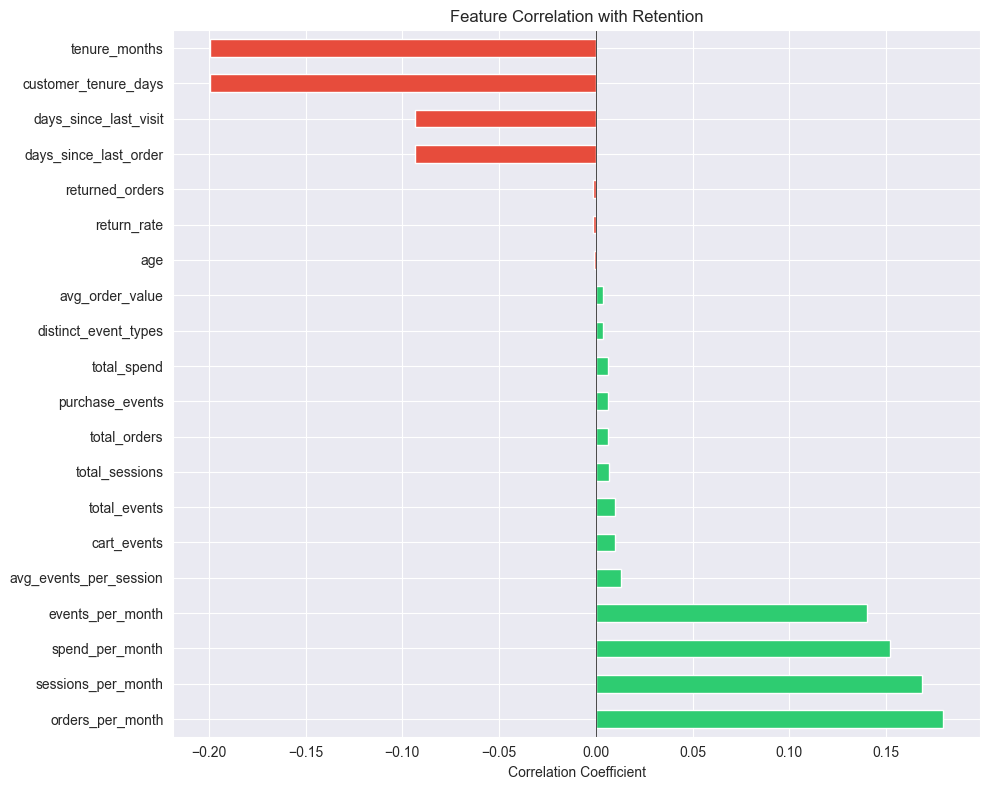

=== Top Correlations with Retention ===
orders_per_month          0.180
sessions_per_month        0.168
spend_per_month           0.152
events_per_month          0.140
avg_events_per_session    0.013
cart_events               0.010
total_events              0.010
total_sessions            0.007
total_orders              0.006
purchase_events           0.006
total_spend               0.006
distinct_event_types      0.004
avg_order_value           0.004
age                      -0.001
return_rate              -0.001
returned_orders          -0.002
days_since_last_order    -0.093
days_since_last_visit    -0.094
customer_tenure_days     -0.199
tenure_months            -0.199
Name: is_retained, dtype: float64


In [38]:
# Updated correlation with target (numerical features only)
numerical_df = df.select_dtypes(include=[np.number]).drop(columns=['user_id'])
correlations = numerical_df.corr()['is_retained'].drop('is_retained').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=correlations.apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
plt.title('Feature Correlation with Retention')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("=== Top Correlations with Retention ===")
print(correlations.round(3))

### Key Takeaway

Retention is primarily driven by **lifecycle stage, recency, and sustained activity intensity**, rather than raw usage volume.

1. **Lifecycle / tenure**: `customer_tenure_days` and `tenure_months` show the strongest negative correlation (r ≈ -0.20), indicating that newer customers are more likely to repurchase within 90 days.
2. **Activity intensity (per-month rates)**: Normalized features such as `orders_per_month`, `sessions_per_month`, `spend_per_month`, and `events_per_month` exhibit the strongest positive relationships (r ≈ 0.14–0.18), highlighting the importance of consistent engagement over time.
3. **Recency signals**: `days_since_last_visit` and `days_since_last_order` show moderate negative correlations (r ≈ -0.09), reinforcing the role of recent activity in predicting short-term retention.
4. **Raw engagement and value metrics**: Lifetime totals and session-level ratios (`total_events`, `total_orders`, `avg_events_per_session`, `total_spend`) show minimal linear correlation, suggesting limited standalone predictive value.

Overall, retention is best explained by how recently and how consistently customers engage, rather than by cumulative usage or spend. Given the generally modest correlations, non-linear models and interaction features (e.g., tenure × recency, tenure × activity rate) are likely needed to capture more complex retention dynamics.

### Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectFromModel

# Define target variable
TARGET = "is_retained"

# Drop unused features
DROP_COLS = [
    "user_id",
    "product_view_events",  # identical to cart_events
    "return_rate_bin",      # only used 
    "tenure_months"     # redundant with customer_tenure_days
    # --- replaced with per-month rates
    "total_orders", "total_sessions", "total_spend", "total_events",
    # --- weak signals
    "age", "return_rate", "returned_orders", "avg_order_value", "distinct_event_types"
]
df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")

# Define target & features
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET], errors="ignore")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# --- Preprocessing pipeline ---
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,  # cleaner column names
)

# Fit preprocess on TRAIN only
X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

feature_names = preprocess.get_feature_names_out()

# --- 6.3 Feature Selection ---
# (A) Remove near-constant features (variance threshold)
vt = VarianceThreshold(threshold=1e-5)  # adjust if needed
X_train_v = vt.fit_transform(X_train_p)
X_test_v  = vt.transform(X_test_p)
vt_names = feature_names[vt.get_support()]

# (B) Model-based selection: L1 Logistic Regression (sparse feature selection)
# Use class_weight='balanced' due to imbalance
l1_clf = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.5,                 # smaller C => stronger regularization => fewer features
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)

selector = SelectFromModel(l1_clf, prefit=False, threshold="median")  # or threshold=1e-6
X_train_sel = selector.fit_transform(X_train_v, y_train)
X_test_sel  = selector.transform(X_test_v)
sel_names = vt_names[selector.get_support()]

print(f"Original features: {X_train.shape[1]}")
print(f"After preprocessing: {len(feature_names)}")
print(f"After variance filter: {X_train_v.shape[1]}")
print(f"After L1 selection: {X_train_sel.shape[1]}")

# Optional: inspect selected features
selected_features = pd.Series(sel_names).sort_values()
selected_features.head(30), selected_features.tail(30)

### Feature Selection

In [ ]:
# Define target and features
y = df['is_retained']
X = df.drop(columns=['is_retained', 'user_id', 'return_rate_bin'])

print(f"Features: {list(X.columns)}")
print(f"Target: {y.name} (0 = Churned, 1=Retained)")

## 7. Model Development

### Baseline

In [ ]:
# Baseline: Predict no one returns
baseline_accuracy = 1 - y_test.mean()
print(f"--- Baseline Model (Predict No Retention) ---")
print(f"Accuracy: {baseline_accuracy:.1%}")
print(f"Recall: 0.0% (No Retained users predicted)")
print(f"PR-AUC: {retention_rate:.2%} (proportion of positive class)")
print(f"\nThis is the bar the model must beat.")

### Model Comparison

In [ ]:
# Calculate scale weight for XGBoost
# Logic: sum(majority) / sum(minority)
scale_pos_weight = (y_train == 0).sum() / (y_train ==1).sum()
print(f"Computed scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

In [ ]:
%%time
# 1. Define models with class imbalance handling
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        max_iter=1000,      # prevent convergence warnings
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', 
        n_estimators=100, 
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,  # handle class imbalance
        n_estimators=150,    # enough trees to converge without excessive computation
        max_depth=3,         # shallow trees to prevent overfitting
        learning_rate=0.1,   # standard for initial comparison
        random_state=42,
        eval_metric='aucpr'
    )
}

# 2. Iterate & Evaluate
results = []

for name, model in models.items():
    # Use scaled df for Logistic Regression, normal for Trees
    if name == 'Logistic Regression':
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    results.append({
        'Model': name,
        'PR-AUC': average_precision_score(y_test, y_prob),  # primary metric - better for imbalanced df
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
    })

# 3. Create Comparison DataFrame
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.sort_values(by='PR-AUC', ascending=False).style.background_gradient(cmap='Blues'))

### Model Selection

XGBoost achieved highest PR-AUC: 0.159. Notably, Logistic Regression performed competitively (PR-AUC: 0.156), suggesting the signal is largely driven by linear relationship - particularly recency.

XGBoost was selected for its marginally better performance and ability to capture non-linear interactions, though Logistic Regression would be a reasonable choice if interpretability were the primary concern.

In [ ]:
# Select best model based on PR-AUC (primary metric for imbalanced classification)
best_model_name = results_df['PR-AUC'].idxmax()
best_model = models[best_model_name]

print(f"Best Model: {best_model_name} with PR-AUC: {results_df.loc[best_model_name, 'PR-AUC']:.3f}")

In [ ]:
# Save the model (for the App later)
joblib.dump(best_model, MODEL_PATH)

## 8. Model Evaluation

In [ ]:
# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

### Classification Report

In [ ]:
# Classification Report
print(f"--- Classification Report: {best_model_name} ---")
print(classification_report(y_test, y_pred))

### Confusion Matrix Interpretation

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Churned', 'Retained'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Predicting Churn)")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretation:")
print(f"  True Positives (correctly identified loyalists): {tp:,}")
print(f"  False Positives (predicted loyal, actually churned): {fp:,}")
print(f"  False Negatives (missed loyalists): {fn:,}")
print(f"  True Negatives (correctly identified churned): {tn:,}")

### Precision-Recall Curve (Lift Chart)

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    best_model, X_test, y_test, name="XGBoost"
)
_ = display.ax_.set_title("Precision-Recall Curve (Repurchase Prediction)")

## 9. Model Interpretation

### Feature Importance


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(df=feature_importance.head(10), x='importance', y='feature', hue='feature', palette='viridis')
plt.title("Feature Importance: What Predicts Repeat Purchase?")
plt.show()

### Profit Simulation


In [ ]:
# Scenario: 
# - We offer a $5 discount to users we think will churn (Target = 1).
# - If we save them, we gain $50 in CLV (Customer Lifetime Value).
# - Success rate: 20%
# - We want to find the optimal targeting threshold to maximize profit.

results = pd.DataFrame({
    'actual_churned': y_test.values,
    'churn_prob': y_prob # Probability of Churn
})

# We target users with low retention probability (High churn risk)
# Let's test different thresholds: "Target everyone below 20% probability", "Below 30%", etc.
thresholds = np.linspace(0, 1, 100)
profits = []

for t in thresholds:
    # Who do we target? (Anyone with probability > t)
    targets = results[results['churn_prob'] > t]
    
    # Costs & gains
    n_campaigns = len(targets)
    cost = n_campaigns * 5 # $5 per coupon
    
    # Assume the campaign saves 20% of the churners we target
    # Real churners in our target list:
    real_churners_targeted = targets[targets['actual_churned'] == 1]
    saved_customers = len(real_churners_targeted) * 0.2
    
    revenue = saved_customers * 50 # $50 CLV gained per saved customer
    
    profit = revenue - cost
    profits.append(profit)
    

# Plot the Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, color='green', linewidth=3)
plt.axhline(0, color='black', linestyle='--')
plt.title("Projected Profit by Targeting Threshold")
plt.xlabel("Targeting Threshold (Probability of Retention)")
plt.ylabel("Estimated Profit ($)")

# Find peak profit point
max_profit = max(profits)
optimal_threshold = thresholds[np.argmax(profits)]

plt.annotate(f'Peak: ${max_profit:,.0f} @ {optimal_threshold:.2f}', 
             xy=(optimal_threshold, max_profit), 
             xytext=(optimal_threshold+0.1, max_profit),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Strategy: Target customers with < {optimal_threshold:.0%} retention probability for maximum profit of ${max_profit:.2f}")

## 10. Conclusion & Next Steps

### Key Findings:

- `days_since_last_order`, `total_orders`, and `avg_order_value` are the top predictors of churn.


### Recommendations:

- Target users with `days_since_last_order` < 

In [ ]:
# TODO: finalize recommendation based on modeling results